# Data Challenge – Team 16: Coffee Shop Sales

**Student Name:** Arifuzzaman  
**Student ID:** 7088214
**Dataset:** team16_coffeeshop.csv  

## Objective
Analyze coffee shop sales data to understand revenue patterns, customer behavior, and sales performance across categories and locations.

## Questions
1. Which time of day generates the most revenue?
2. What is the average transaction value by item category?
3. Do loyalty members spend more on average?
4. Which location has the highest sales?

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv("team16_coffeeshop.csv")
df.head()

,transaction_id,date,time_of_day,item_category,size,price,payment_type,loyalty_member,location,staff_id
0,1,2023-12-19,Evening,Tea,Small,2.00,Cash,False,Store C,9
1,2,2023-12-23,Morning,Coffee,Small,3.14,Cash,True,Store A,5
2,3,2023-03-22,Afternoon,Pastry,Small,2.00,Mobile,True,Store A,13
3,4,2023-06-28,Morning,Coffee,Large,2.00,Card,False,Store B,9
4,5,2023-04-09,Morning,Coffee,Large,2.00,Card,True,Store C,14


## Data Exploration

In [26]:
from google.colab import files
uploaded = files.upload()

Saving team16_coffeeshop.csv to team16_coffeeshop (2).csv


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  1400 non-null   int64  
 1   date            1400 non-null   object 
 2   time_of_day     1400 non-null   object 
 3   item_category   1400 non-null   object 
 4   size            1332 non-null   object 
 5   price           1400 non-null   float64
 6   payment_type    1345 non-null   object 
 7   loyalty_member  1400 non-null   bool   
 8   location        1400 non-null   object 
 9   staff_id        1400 non-null   int64  
dtypes: bool(1), float64(1), int64(2), object(6)
memory usage: 99.9+ KB


In [28]:
df.describe(include='all')

,transaction_id,date,time_of_day,item_category,size,price,payment_type,loyalty_member,location,staff_id
count,1400.0000,1400,1400,1400,1332,1400.000000,1345,1400,1400,1400.000000
unique,NaN,355,3,5,3,NaN,3,2,3,NaN
top,NaN,2023-06-27,Morning,Coffee,Medium,NaN,Card,False,Store B,NaN
freq,NaN,11,695,687,673,NaN,882,775,471,NaN
mean,700.5000,NaN,NaN,NaN,NaN,3.340100,NaN,NaN,NaN,7.555714
std,404.2895,NaN,NaN,NaN,NaN,1.940161,NaN,NaN,NaN,3.994426
min,1.0000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,1.000000
25%,350.7500,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,4.000000
50%,700.5000,NaN,NaN,NaN,NaN,2.430000,NaN,NaN,NaN,8.000000
75%,1050.2500,NaN,NaN,NaN,NaN,4.010000,NaN,NaN,NaN,11.000000


In [29]:
df.isnull().sum()

,0
transaction_id,0
date,0
time_of_day,0
item_category,0
size,68
price,0
payment_type,55
loyalty_member,0
location,0
staff_id,0


## Data Cleaning
- Convert price to numeric
- Standardize loyalty_member
- Handle missing values

In [30]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')

df['loyalty_member'] = df['loyalty_member'].astype(str).str.lower().map({
    'true': True,
    'false': False
})

df['price'].fillna(df['price'].mean(), inplace=True)

df.head()

/tmp/ipykernel_16886/4258865739.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['price'].fillna(df['price'].mean(), inplace=True)


,transaction_id,date,time_of_day,item_category,size,price,payment_type,loyalty_member,location,staff_id
0,1,2023-12-19,Evening,Tea,Small,2.00,Cash,False,Store C,9
1,2,2023-12-23,Morning,Coffee,Small,3.14,Cash,True,Store A,5
2,3,2023-03-22,Afternoon,Pastry,Small,2.00,Mobile,True,Store A,13
3,4,2023-06-28,Morning,Coffee,Large,2.00,Card,False,Store B,9
4,5,2023-04-09,Morning,Coffee,Large,2.00,Card,True,Store C,14


## Data Cleaning Summary

- Missing value handling:  
Missing values in the price column were handled by replacing them with the mean value to maintain dataset consistency without removing records.

- Data type corrections:  
The price column was converted to numeric format to ensure accurate calculations. The loyalty_member column was standardized into boolean values (True/False) for proper grouping and analysis.

- Inconsistency resolution:  
Inconsistencies in the loyalty_member column (such as TRUE/FALSE stored as text) were standardized into consistent boolean values to ensure reliable analysis.

- Invalid data removal:  
No invalid or unrealistic values (such as negative prices) were found in the dataset. Therefore, no records were removed during the cleaning process.

## Q1: Which time of day generates the most revenue?

In [31]:
q1 = df.groupby('time_of_day')['price'].sum().sort_values(ascending=False)
q1

,price
time_of_day,
Morning,2298.87
Afternoon,1636.45
Evening,740.82


Insight:  
Morning generates the highest revenue at 2298.87, significantly higher than Afternoon (1636.45) and Evening (740.82).  
This indicates that customer activity and spending are highest in the morning, making it the peak sales period for the coffee shop.

## Q2: What is the average transaction value by item category?

In [32]:
q2 = df.groupby('item_category')['price'].mean().sort_values(ascending=False)
q2

,price
item_category,
Tea,3.471765
Coffee,3.428734
Sandwich,3.252208
Pastry,3.209555
Other,2.767143


Insight:  
Tea has the highest average transaction value at approximately 3.47, followed closely by Coffee at 3.43.  
This suggests that tea and coffee purchases generate more revenue per transaction, while items in the "Other" category have the lowest average value.

## Q3: Do loyalty members spend more on average?

In [33]:
q3 = df.groupby('loyalty_member')['price'].mean()
q3

,price
loyalty_member,
False,3.320748
True,3.364096


Insight:  
Loyalty members spend slightly more on average (3.36) compared to non-members (3.32).  
Although the difference is small, this suggests that the loyalty program has a positive but limited impact on customer spending behavior.

## Q4: Which location has the highest sales?

In [34]:
q4 = df.groupby('location')['price'].sum().sort_values(ascending=False)
q4

,price
location,
Store A,1602.73
Store B,1573.14
Store C,1500.27


Insight:  
Store A generates the highest total sales at 1602.73, followed by Store B (1573.14) and Store C (1500.27).  
This indicates that Store A is the top-performing location, although sales across all stores are relatively similar.

## Visualizations

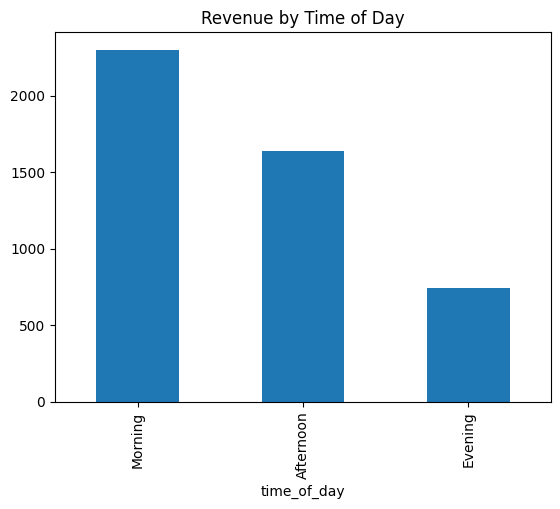

In [35]:
q1.plot(kind='bar', title='Revenue by Time of Day')
plt.show()

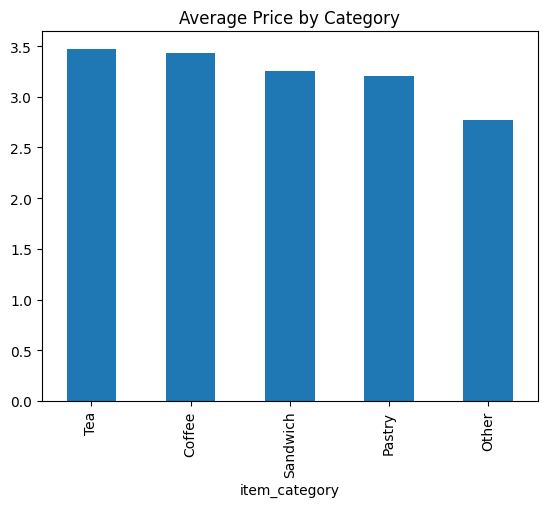

In [36]:
q2.plot(kind='bar', title='Average Price by Category')
plt.show()

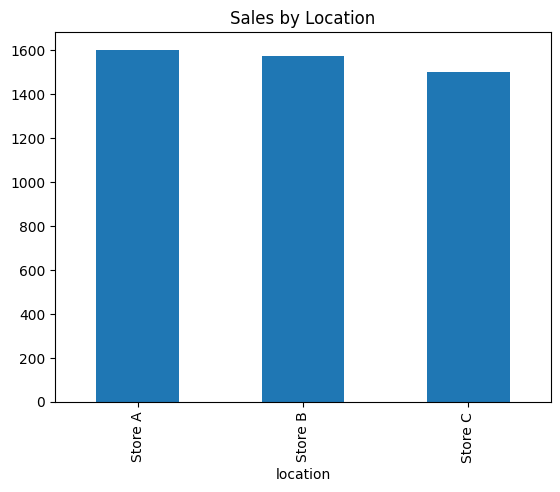

In [37]:
q4.plot(kind='bar', title='Sales by Location')
plt.show()

## Key Findings

- Morning generates the highest revenue at 2298.87, making it the most important sales period for the coffee shop, while afternoon and evening contribute less.

- Tea and coffee have the highest average transaction values (3.47 and 3.43), indicating that beverage items generate more revenue per purchase compared to other categories.

- Loyalty members spend slightly more on average (3.36) than non-members (3.32), suggesting a small positive impact of the loyalty program on customer spending.

- Store A has the highest total sales at 1602.73, but the differences between all three stores are relatively small, indicating similar performance across locations.

These findings highlight patterns in customer behavior, product performance, and store-level sales.

## Conclusion

This analysis examined coffee shop sales data to understand revenue patterns, customer spending behavior, and store performance. The results show that the morning is the busiest and most profitable time of day, and that beverage categories such as tea and coffee contribute the highest value per transaction.

The analysis also indicates that loyalty members spend slightly more than non-members, although the difference is minimal. In addition, Store A performs slightly better than the other locations, but overall sales are fairly consistent across all stores.

Overall, this analysis provides useful insights that can help the coffee shop improve operations, focus on high-performing products, and better understand customer behavior to support future business decisions.